# HPO Quantum — REUP-HE v3 (lite) + tuning gamma | Anti-Leakage

Perbaikan setelah v2 gagal (entanglement berat -> kernel concentration). **v3 = ringan**: `reup_lite` (turunan star, 1 hub/rep berputar, multi-basis) dibandingkan dengan `star`, **dengan sweep gamma {0.5,1,2}** (bandwidth RBF PQK — pengungkit utama). PCA={3,5,8,12}, C={1,10}, lambda=0.1, reps=2, bandwidth=0.5. Output ke `output_qml/REUP-HE_v3/`.

## Setup

In [2]:
import os, sys, datetime, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))   # agar paket 'model' bisa diimpor

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score, average_precision_score)
from model.quantum.qsvc import QSVCWrapper

import warnings
warnings.filterwarnings('ignore')

# --- folder output khusus model ini; simpan semua figur DPI 300 ---
OUTDIR = '../output_qml/REUP-HE_v3'
os.makedirs(OUTDIR, exist_ok=True)
def savefig(_name):
    plt.savefig(OUTDIR + '/%s.png' % _name, dpi=300, bbox_inches='tight')

In [3]:
dataset_path = '../dataset/datasets.csv'
feature_cols = ['MQ3', 'TGS822', 'TGS2602', 'MQ5', 'MQ138', 'TGS2620',
                'TGS813', 'TGS2600', 'TGS2611', 'TGS2603', 'Humidity', 'Celsius']
target_col = 'Kategori'
group_col  = 'Sampling_ID'

CV_MODE       = 'group'
n_splits      = 5
USE_PCA       = True
random_states = [42]
select_by     = 'composite'

PCA_COMPONENTS = [3, 5, 8, 12]      # = n_qubits (ikut PCA otomatis)

# ===== Quantum (PQK) — lambda_ & gamma STATIS (prinsipiil) =====
Q_MODE       = 'pqk'
Q_LAMBDA     = 0.1
Q_GAMMA      = 1.0
Q_MLANDMARKS = 100                  # Nystrom (QCAT/QXGB); QSVC = None

# ===== SEARCH SPACE (feature map = "model") =====
_KERNELS = ['star', 'reup_lite']
SEARCH_SPACES = {'QSVC-' + k: {'C': [1, 10], 'gamma': [0.1, 0.25, 0.5, 1.0, 2.0]} for k in _KERNELS}

In [4]:
df = pd.read_csv(dataset_path)
print('Shape  :', df.shape)
print('Groups :', df[group_col].nunique(), 'Sampling_ID |', df['Chop_ID'].nunique(), 'Chop_ID')
df[feature_cols + [target_col, group_col]].head()

Shape  : (10409, 130)
Groups : 274 Sampling_ID | 69 Chop_ID


,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Kategori,Sampling_ID
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,D,TR612_1
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,D,TR612_1
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,D,TR612_1
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,D,TR612_1
4,90.0,42.0,48.0,132.0,95.0,46.0,552.0,289.0,546.0,371.0,46.4,38.8,D,TR612_1


Distribusi per BARIS (n=10409):
Kategori
E    4649
D    2317
C    2287
A     927
B     229
Name: count, dtype: int64

Distribusi per SAMPLING_ID (n=274):
Kategori
E    132
C     58
D     55
A     20
B      9
Name: count, dtype: int64


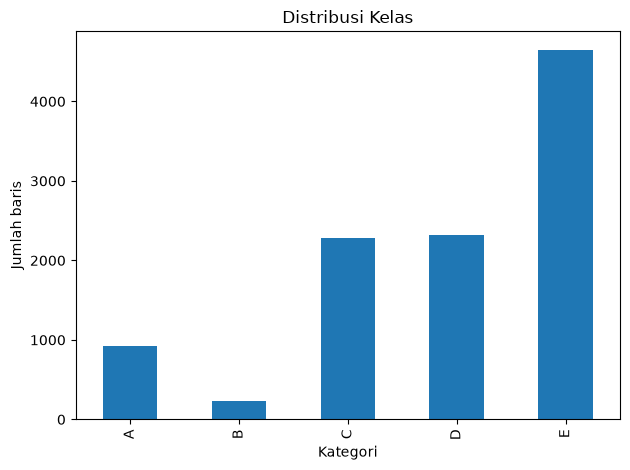

In [5]:
print('Distribusi per BARIS (n=%d):' % len(df))
print(df[target_col].value_counts())
print('\nDistribusi per SAMPLING_ID (n=%d):' % df[group_col].nunique())
print(df.groupby(group_col)[target_col].first().value_counts())
ax = df[target_col].value_counts().sort_index().plot(kind='bar')
ax.set_xlabel('Kategori'); ax.set_ylabel('Jumlah baris'); ax.set_title('Distribusi Kelas')
plt.tight_layout(); savefig('01_distribusi_kelas'); plt.show()

In [6]:
# Bukti rawan leakage: variasi antar-baris dalam 1 sampling << variasi keseluruhan
within  = df.groupby(group_col)[feature_cols].std().mean()
overall = df[feature_cols].std()
print('Rasio std(dalam-grup)/std(keseluruhan) [%]:')
print((within / overall * 100).round(1).sort_values())

Rasio std(dalam-grup)/std(keseluruhan) [%]:
TGS2600      5.5
MQ5          7.3
TGS2603      9.4
Humidity    11.0
Celsius     11.6
TGS2611     14.8
TGS2620     16.7
TGS822      17.4
MQ3         17.5
TGS2602     18.7
MQ138       20.9
TGS813      22.5
dtype: float64


## CV + encoding

In [7]:
le = LabelEncoder().fit(df[target_col])
X_all      = df[feature_cols].values
y_all      = le.transform(df[target_col])
groups_all = df[group_col].values
classes    = np.arange(len(le.classes_))
names      = le.classes_
print('Kelas:', dict(zip(classes.tolist(), names)))

def make_cv(rs):
    if CV_MODE == 'group':
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=rs)
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rs)

folds = list(make_cv(random_states[0]).split(X_all, y_all, groups_all))
for k, (tr, te) in enumerate(folds, start=1):
    if CV_MODE == 'group':
        assert set(groups_all[tr]).isdisjoint(set(groups_all[te])), 'BOCOR fold %d' % k
    print('Fold %d | train %5d | test %5d' % (k, len(tr), len(te)))

Kelas: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
Fold 1 | train  8316 | test  2093
Fold 2 | train  8331 | test  2078
Fold 3 | train  8340 | test  2069
Fold 4 | train  8335 | test  2074
Fold 5 | train  8314 | test  2095


In [8]:
# Diagnostik: jumlah kelas per fold (train & test)
test_counts  = pd.DataFrame({'F%d' % (k+1): pd.Series(y_all[te]).value_counts().reindex(classes, fill_value=0).values
                             for k, (tr, te) in enumerate(folds)}, index=names)
train_counts = pd.DataFrame({'F%d' % (k+1): pd.Series(y_all[tr]).value_counts().reindex(classes, fill_value=0).values
                             for k, (tr, te) in enumerate(folds)}, index=names)
print('TEST per kelas tiap fold:'); print(test_counts.to_string())
print('\nProporsi TEST per kelas (%):'); print((test_counts / test_counts.sum() * 100).round(1).to_string())
print('\nTRAIN per kelas tiap fold:'); print(train_counts.to_string())
if CV_MODE == 'group':
    grp = pd.DataFrame({'F%d' % (k+1): df.iloc[te].groupby(group_col)[target_col].first()
                        .value_counts().reindex(names, fill_value=0).values
                        for k, (tr, te) in enumerate(folds)}, index=names)
    print('\nGRUP (Sampling_ID) TEST per kelas tiap fold:'); print(grp.to_string())

TEST per kelas tiap fold:
    F1   F2   F3   F4   F5
A  194  185  176  177  195
B   48   38   47   49   47
C  459  456  455  460  457
D  463  468  464  459  463
E  929  931  927  929  933

Proporsi TEST per kelas (%):
     F1    F2    F3    F4    F5
A   9.3   8.9   8.5   8.5   9.3
B   2.3   1.8   2.3   2.4   2.2
C  21.9  21.9  22.0  22.2  21.8
D  22.1  22.5  22.4  22.1  22.1
E  44.4  44.8  44.8  44.8  44.5

TRAIN per kelas tiap fold:
     F1    F2    F3    F4    F5
A   733   742   751   750   732
B   181   191   182   180   182
C  1828  1831  1832  1827  1830
D  1854  1849  1853  1858  1854
E  3720  3718  3722  3720  3716

GRUP (Sampling_ID) TEST per kelas tiap fold:
   F1  F2  F3  F4  F5
A   4   4   4   4   4
B   2   1   2   2   2
C  12  11  11  12  12
D  11  11  11  11  11
E  26  26  26  27  27


## Visualisasi distribusi

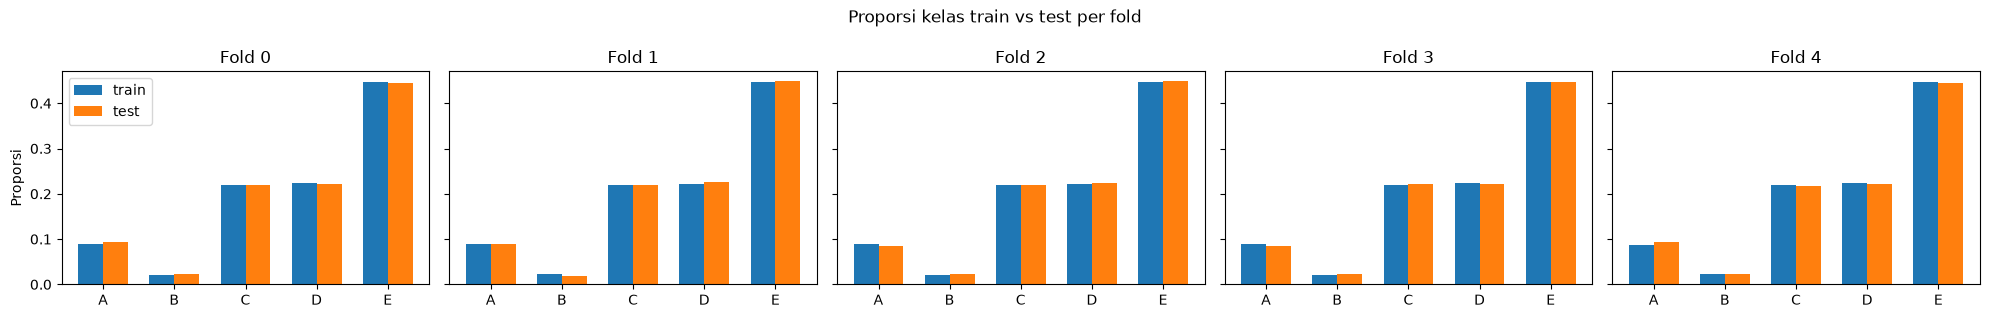

In [9]:
idx = np.arange(len(names)); w = 0.35
fig, axes = plt.subplots(1, len(folds), figsize=(4 * len(folds), 3.2), sharey=True)
for ax, (k, (tr, te)) in zip(axes, enumerate(folds)):
    tr_p = pd.Series(y_all[tr]).value_counts(normalize=True)
    te_p = pd.Series(y_all[te]).value_counts(normalize=True)
    ax.bar(idx - w/2, [tr_p.get(i, 0) for i in range(len(names))], w, label='train')
    ax.bar(idx + w/2, [te_p.get(i, 0) for i in range(len(names))], w, label='test')
    ax.set_xticks(idx); ax.set_xticklabels(names); ax.set_title('Fold %d' % k)
axes[0].set_ylabel('Proporsi'); axes[0].legend()
plt.suptitle('Proporsi kelas train vs test per fold'); plt.tight_layout(); savefig('02_proporsi_kelas_per_fold'); plt.show()

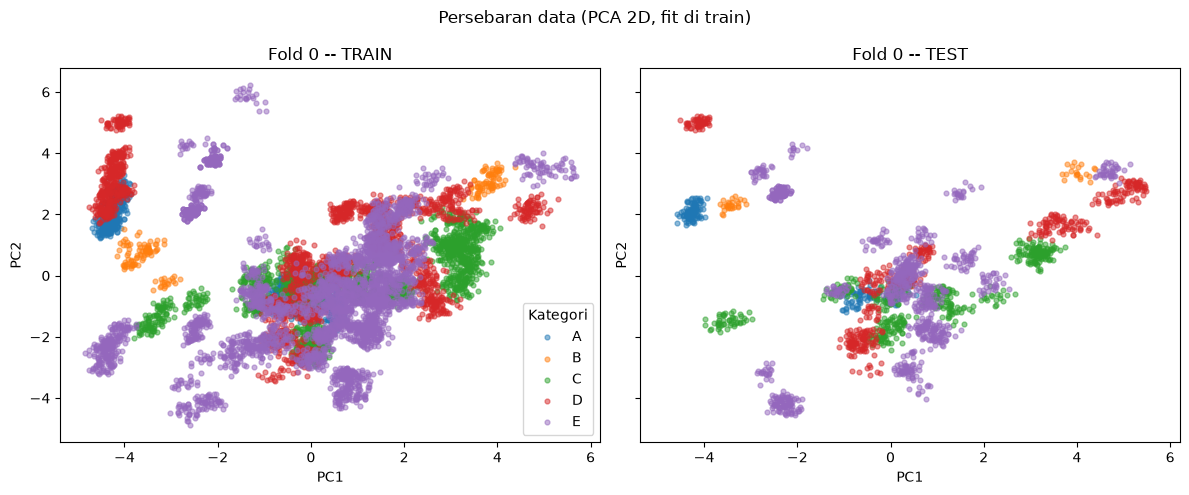

In [10]:
tr, te = folds[0]
prep = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2))]).fit(X_all[tr])
Z_tr, Z_te = prep.transform(X_all[tr]), prep.transform(X_all[te])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (Z, yy, ttl) in zip(axes, [(Z_tr, y_all[tr], 'TRAIN'), (Z_te, y_all[te], 'TEST')]):
    for i, cls in enumerate(names):
        m = yy == i
        ax.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.5, label=cls)
    ax.set_title('Fold 0 -- %s' % ttl); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes[0].legend(title='Kategori')
plt.suptitle('Persebaran data (PCA 2D, fit di train)'); plt.tight_layout(); savefig('03_pca2d_train_test'); plt.show()

## Logger + checkpoint (resume)

In [11]:
os.makedirs('../output_qml/REUP-HE_v3', exist_ok=True)
LOG_TXT = '../output_qml/REUP-HE_v3/hpo_log.txt'         # log detail (append, stabil antar-run)
CKPT    = '../output_qml/REUP-HE_v3/hpo_results.jsonl'   # checkpoint utk resume
RESET   = False                         # True = mulai dari nol (hapus log & checkpoint)

if RESET:
    for p in (LOG_TXT, CKPT):
        if os.path.exists(p):
            os.remove(p)

def log(line=''):
    print(line)
    with open(LOG_TXT, 'a', encoding='utf-8') as f:
        f.write(line + '\n')

done = {}
if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f:
        for ln in f:
            if ln.strip():
                r = json.loads(ln); done[r['config']] = r

def save_ckpt(rec):
    with open(CKPT, 'a', encoding='utf-8') as f:
        f.write(json.dumps(rec, default=float) + '\n')

stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# Header SESSION ditulis ke FILE secara LAZY -- hanya saat ada config BARU yang dijalankan.
# Jadi kalau semua config sudah di checkpoint, rerun TIDAK menambah baris apa pun ke log (anti-redundan).
_session = {'logged': False}
def ensure_session():
    if not _session['logged']:
        with open(LOG_TXT, 'a', encoding='utf-8') as f:
            f.write('\n# ==== SESSION %s | CV_MODE=%s | n_splits=%d ====\n' % (stamp, CV_MODE, n_splits))
        _session['logged'] = True

print('Checkpoint: %d config sudah selesai (akan dilewati). Log:' % len(done), os.path.abspath(LOG_TXT))

Checkpoint: 55 config sudah selesai (akan dilewati). Log: e:\Quantum Computing\Github\quantum-multiclass-classification\output_qml\REUP-HE_v3\hpo_log.txt


## Pipeline, metrik, runner HPO

In [12]:
def make_pipe(model):
    steps = [('scaler', StandardScaler())]
    if USE_PCA:
        steps.append(('pca', PCA()))   # n_components dituning via grid (pca__n_components)
    steps.append(('model', model))
    return Pipeline(steps)

_SHORT = {'C': 'C', 'gamma': 'g', 'degree': 'd', 'n_estimators': 'n', 'max_depth': 'md',
          'learning_rate': 'lr', 'reg_lambda': 'lam', 'depth': 'depth', 'iterations': 'it',
          'l2_leaf_reg': 'l2', 'n_components': 'pca'}

def fmt_params(params):
    parts = []
    for k in sorted(params):                 # urut -> nama config stabil antar-run (penting utk resume)
        key = k.split('__')[-1]
        v = params[k]
        val = ('%g' % v) if isinstance(v, float) else str(v)
        parts.append('%s%s' % (_SHORT.get(key, key), val))
    return '_'.join(parts) if parts else 'default'

def fold_metrics(y_true, y_pred, y_proba):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    try:
        auroc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro', labels=classes)
    except Exception:
        auroc = np.nan
    try:
        prauc = average_precision_score(label_binarize(y_true, classes=classes), y_proba, average='macro')
    except Exception:
        prauc = np.nan
    return acc, prec, rec, f1, mcc, auroc, prauc

def composite_score(f1_m, mcc_m, prauc_m):
    # minority-aware: macro-F1, MCC dinormalisasi [0,1], PRAUC macro -- Accuracy & AUROC sengaja tidak dipakai
    return np.nanmean([f1_m, (mcc_m + 1) / 2, prauc_m])

In [13]:
def run_hpo(model_name, base_model, param_grid):
    results = []
    header_written = False
    for params in ParameterGrid(param_grid):
        for ridx, rs in enumerate(random_states, start=1):
            name = '%s_R%d_%s' % (model_name, ridx, fmt_params(params))
            if name in done:                       # RESUME: pakai checkpoint; skip cuma ke console (tidak ke file)
                results.append(done[name]); print('  skip %s (sudah ada di checkpoint)' % name); continue
            ensure_session()                       # header SESSION ditulis sekali, hanya saat ada kerja baru
            if not header_written:
                log(''); log('=== MODEL: %s ===' % model_name); header_written = True
            log('  ▶ %s' % name)
            cv = make_cv(rs)
            accs, precs, recs, f1s, mccs, aurocs, praucs = [], [], [], [], [], [], []
            tr_accs, tr_f1s = [], []
            for i, (tr, te) in enumerate(cv.split(X_all, y_all, groups_all), start=1):
                pipe = make_pipe(clone(base_model)); pipe.set_params(**params)
                pipe.fit(X_all[tr], y_all[tr])
                pred_tr = np.asarray(pipe.predict(X_all[tr])).ravel().astype(int)
                tr_accs.append(accuracy_score(y_all[tr], pred_tr))
                tr_f1s.append(f1_score(y_all[tr], pred_tr, average='macro', zero_division=0))
                pred  = np.asarray(pipe.predict(X_all[te])).ravel().astype(int)
                proba = pipe.predict_proba(X_all[te])
                acc, prec, rec, f1, mcc, au, pr = fold_metrics(y_all[te], pred, proba)
                accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1)
                mccs.append(mcc); aurocs.append(au); praucs.append(pr)
                log('    F%d → Acc=%.4f | Prec=%.4f | Rec=%.4f | F1=%.4f | MCC=%.4f | AUROC=%.4f | PRAUC=%.4f'
                    % (i, acc, prec, rec, f1, mcc, au, pr))
            acc_m, prec_m, rec_m, f1_m = np.nanmean(accs), np.nanmean(precs), np.nanmean(recs), np.nanmean(f1s)
            mcc_m, au_m, pr_m = np.nanmean(mccs), np.nanmean(aurocs), np.nanmean(praucs)
            comp = composite_score(f1_m, mcc_m, pr_m)
            tr_acc_m, tr_f1_m = np.nanmean(tr_accs), np.nanmean(tr_f1s)
            log('  ✅ %s → Acc:%.4f±%.4f | Prec:%.4f±%.4f | Rec:%.4f±%.4f | F1:%.4f±%.4f | MCC:%.4f±%.4f | AUROC:%.4f±%.4f | PRAUC:%.4f±%.4f | Composite:%.4f'
                % (name, acc_m, np.nanstd(accs), prec_m, np.nanstd(precs), rec_m, np.nanstd(recs),
                   f1_m, np.nanstd(f1s), mcc_m, np.nanstd(mccs), au_m, np.nanstd(aurocs), pr_m, np.nanstd(praucs), comp))
            log('')
            rec_ = {'model': model_name, 'config': name, 'params': params,
                    'acc': acc_m, 'acc_std': np.nanstd(accs),
                    'precision': prec_m, 'precision_std': np.nanstd(precs),
                    'recall': rec_m, 'recall_std': np.nanstd(recs),
                    'f1': f1_m, 'f1_std': np.nanstd(f1s),
                    'mcc': mcc_m, 'mcc_std': np.nanstd(mccs),
                    'auroc': au_m, 'auroc_std': np.nanstd(aurocs),
                    'prauc': pr_m, 'prauc_std': np.nanstd(praucs),
                    'composite': comp,
                    'train_acc': tr_acc_m, 'train_f1': tr_f1_m,
                    'gap_acc': tr_acc_m - acc_m, 'gap_f1': tr_f1_m - f1_m}
            save_ckpt(rec_); done[name] = rec_; results.append(rec_)
    return results

## Bangun model + tampilkan search space

In [14]:
RS = 42

class QSVCauto(QSVCWrapper):
    # n_qubits = n_features mengikuti dimensi PCA; expose classes_ utk pipeline/OOF
    def fit(self, X, y):
        self.n_qubits = X.shape[1]; self.n_features = X.shape[1]
        super().fit(X, y)
        self.classes_ = np.unique(y)
        return self

def _mk(kernel):
    return QSVCauto(kernel=kernel, mode=Q_MODE, lambda_=Q_LAMBDA, gamma=Q_GAMMA,
                    m_landmarks=None, n_measurements=None,
                    class_weight='balanced', random_state=RS)

BASE_MODELS = {name: _mk(name.split('QSVC-', 1)[1]) for name in SEARCH_SPACES}

def build_grid(name):
    grid = {'model__' + k: v for k, v in SEARCH_SPACES[name].items()}
    if USE_PCA:
        grid['pca__n_components'] = PCA_COMPONENTS
    return grid

specs = [(name, BASE_MODELS[name], build_grid(name)) for name in BASE_MODELS]
print('=== SEARCH SPACE (QSVC-PQK) ===  lambda=%s gamma=%s' % (Q_LAMBDA, Q_GAMMA))
for name in BASE_MODELS:
    print('%-14s | %2d config | %s + pca%s' % (name, len(list(ParameterGrid(build_grid(name)))), SEARCH_SPACES[name], PCA_COMPONENTS))
total = sum(len(list(ParameterGrid(build_grid(n)))) for n in BASE_MODELS)
print('TOTAL: %d config x %d fold = %d fit (QSVC-PQK, data penuh)' % (total, n_splits, total * n_splits))

=== SEARCH SPACE (QSVC-PQK) ===  lambda=0.1 gamma=1.0
QSVC-star      | 40 config | {'C': [1, 10], 'gamma': [0.1, 0.25, 0.5, 1.0, 2.0]} + pca[3, 5, 8, 12]
QSVC-reup_lite | 40 config | {'C': [1, 10], 'gamma': [0.1, 0.25, 0.5, 1.0, 2.0]} + pca[3, 5, 8, 12]
TOTAL: 80 config x 5 fold = 400 fit (QSVC-PQK, data penuh)


## Jalankan HPO

In [15]:
all_results = []
for model_name, base_model, grid in specs:
    all_results += run_hpo(model_name, base_model, grid)
print('\nSELESAI. Total config:', len(all_results))
print('Log:', os.path.abspath(LOG_TXT), '| Checkpoint:', os.path.abspath(CKPT))

  skip QSVC-star_R1_C1_g0.1_pca3 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.1_pca5 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.1_pca8 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.1_pca12 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.25_pca3 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.25_pca5 (sudah ada di checkpoint)
  skip QSVC-star_R1_C1_g0.25_pca8 (sudah ada di checkpoint)

=== MODEL: QSVC-star ===
  ▶ QSVC-star_R1_C1_g0.25_pca12
    F1 → Acc=0.8930 | Prec=0.8941 | Rec=0.8302 | F1=0.8418 | MCC=0.8482 | AUROC=0.9840 | PRAUC=0.9533
    F2 → Acc=0.9591 | Prec=0.9706 | Rec=0.9498 | F1=0.9588 | MCC=0.9408 | AUROC=0.9983 | PRAUC=0.9948
    F3 → Acc=0.9159 | Prec=0.9313 | Rec=0.8969 | F1=0.9118 | MCC=0.8792 | AUROC=0.9942 | PRAUC=0.9801
    F4 → Acc=0.9026 | Prec=0.8877 | Rec=0.8639 | F1=0.8658 | MCC=0.8624 | AUROC=0.9885 | PRAUC=0.9460
    F5 → Acc=0.8864 | Prec=0.8951 | Rec=0.9059 | F1=0.8985 | MCC=0.8396 | AUROC=0.9865 | PRAUC=0.9676
  ✅ QSVC-star_R

## Komparasi best-param per model

In [16]:
res_df = pd.DataFrame(all_results)
best = res_df.loc[res_df.groupby('model')[select_by].idxmax()].sort_values(select_by, ascending=False)
show = ['model', 'config', 'acc', 'precision', 'recall', 'f1', 'mcc', 'auroc', 'prauc', 'composite']
print(best[show].round(4).to_string(index=False))

# Tulis ke log HANYA jika ada config baru sesi ini (anti-redundan saat rerun cached)
if _session['logged']:
    log(''); log('================ KOMPARASI BEST PARAM PER MODEL (by %s) ================' % select_by)
    for _, r in best.iterrows():
        log('%-12s | %-40s | Acc:%.4f±%.4f | Prec:%.4f±%.4f | Rec:%.4f±%.4f | F1:%.4f±%.4f | MCC:%.4f | AUROC:%.4f | PRAUC:%.4f | Composite:%.4f' % (
            r['model'], r['config'], r['acc'], r['acc_std'], r['precision'], r['precision_std'],
            r['recall'], r['recall_std'], r['f1'], r['f1_std'], r['mcc'], r['auroc'], r['prauc'], r['composite']))

# CSV nama TETAP (di-overwrite tiap run, tidak menumpuk)
res_df.to_csv('../output_qml/REUP-HE_v3/hpo_all.csv', index=False)
best.to_csv('../output_qml/REUP-HE_v3/hpo_best.csv', index=False)
print('\nDisimpan: hpo_all.csv & hpo_best.csv (overwrite)')

         model                        config    acc  precision  recall     f1    mcc  auroc  prauc  composite
     QSVC-star   QSVC-star_R1_C1_g0.25_pca12 0.9114     0.9157  0.8893 0.8953 0.8740 0.9903 0.9683     0.9336
QSVC-reup_lite QSVC-reup_lite_R1_C1_g1_pca12 0.9071     0.9138  0.8759 0.8862 0.8673 0.9901 0.9642     0.9280

================ KOMPARASI BEST PARAM PER MODEL (by composite) ================
QSVC-star    | QSVC-star_R1_C1_g0.25_pca12              | Acc:0.9114±0.0258 | Prec:0.9157±0.0314 | Rec:0.8893±0.0403 | F1:0.8953±0.0401 | MCC:0.8740 | AUROC:0.9903 | PRAUC:0.9683 | Composite:0.9336
QSVC-reup_lite | QSVC-reup_lite_R1_C1_g1_pca12            | Acc:0.9071±0.0275 | Prec:0.9138±0.0343 | Rec:0.8759±0.0480 | F1:0.8862±0.0482 | MCC:0.8673 | AUROC:0.9901 | PRAUC:0.9642 | Composite:0.9280

Disimpan: hpo_all.csv & hpo_best.csv (overwrite)


Rata-rata performa per nilai PCA (lintas semua config):
     n_config  composite      f1     mcc   prauc
pca                                             
3          20     0.7485  0.6881  0.6000  0.7575
5          20     0.8779  0.8352  0.7943  0.9013
8          20     0.9109  0.8699  0.8450  0.9402
12         20     0.9179  0.8721  0.8546  0.9542

PCA terpilih pada best-config tiap model:
  QSVC-star    -> PCA=12 (composite=0.9336)
  QSVC-reup_lite -> PCA=12 (composite=0.9280)

================= REKOMENDASI NILAI PCA =================
PCA terbaik rata-rata lintas config : 12  (mean composite=0.9179)
PCA pada model terbaik (QSVC-star) : 12  (composite=0.9336)
PCA paling sering dipilih : 12  (2 dari 2 model)
=> SARAN dipakai ke depan: PCA n_components = 12

PCA OPTIMAL -> rata-rata terbaik: 12 | model terbaik pakai: 12 | tersering: 12 | SARAN: 12


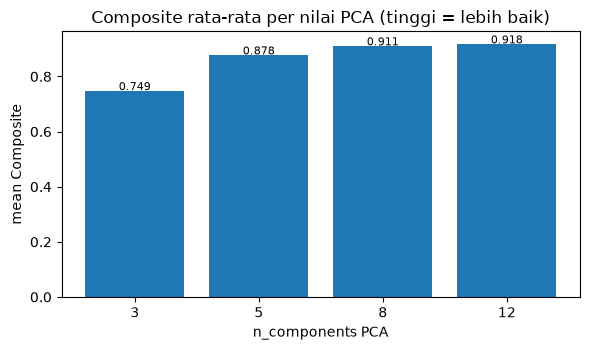

In [17]:
# === Penanda nilai PCA paling optimal (untuk dipakai ke depan) ===
if not USE_PCA:
    print('PCA tidak aktif (USE_PCA=False) -- tidak ada n_components untuk dievaluasi.')
else:
    res_df['pca'] = res_df['params'].apply(lambda p: p.get('pca__n_components'))
    best = best.copy()
    best['pca'] = best['params'].apply(lambda p: p.get('pca__n_components'))

    # Rata-rata performa tiap nilai PCA (lintas SEMUA config & model) -> paling robust
    by_pca = res_df.groupby('pca').agg(
        n_config=('composite', 'size'),
        composite=('composite', 'mean'),
        f1=('f1', 'mean'), mcc=('mcc', 'mean'), prauc=('prauc', 'mean')).round(4)
    print('Rata-rata performa per nilai PCA (lintas semua config):')
    print(by_pca.to_string())

    best_pca_avg = by_pca['composite'].idxmax()
    best_overall = best.sort_values('composite', ascending=False).iloc[0]
    vote = best['pca'].value_counts()

    print('\nPCA terpilih pada best-config tiap model:')
    for _, r in best.sort_values('composite', ascending=False).iterrows():
        print('  %-12s -> PCA=%s (composite=%.4f)' % (r['model'], r['pca'], r['composite']))

    print('\n================= REKOMENDASI NILAI PCA =================')
    print('PCA terbaik rata-rata lintas config : %s  (mean composite=%.4f)' % (best_pca_avg, by_pca.loc[best_pca_avg, 'composite']))
    print('PCA pada model terbaik (%s) : %s  (composite=%.4f)' % (best_overall['model'], best_overall['pca'], best_overall['composite']))
    print('PCA paling sering dipilih : %s  (%d dari %d model)' % (vote.index[0], int(vote.iloc[0]), len(best)))
    print('=> SARAN dipakai ke depan: PCA n_components = %s' % best_pca_avg)

    if _session['logged']:   # tulis ke log hanya jika ada kerja baru sesi ini
        log(''); log('PCA OPTIMAL -> rata-rata terbaik: %s | model terbaik pakai: %s | tersering: %s | SARAN: %s' % (
            best_pca_avg, best_overall['pca'], vote.index[0], best_pca_avg))

    fig, ax = plt.subplots(figsize=(6, 3.6))
    ax.bar(by_pca.index.astype(str), by_pca['composite'])
    for i, v in enumerate(by_pca['composite']):
        ax.text(i, v + 0.002, '%.3f' % v, ha='center', fontsize=8)
    ax.set_xlabel('n_components PCA'); ax.set_ylabel('mean Composite')
    ax.set_title('Composite rata-rata per nilai PCA (tinggi = lebih baik)')
    plt.tight_layout(); savefig('04_composite_per_pca'); plt.show()

Config terbaik pada tiap nilai PCA (lintas semua model):
 pca          model                           config    acc  precision  recall     f1    mcc  auroc  prauc  composite
   3 QSVC-reup_lite  QSVC-reup_lite_R1_C10_g0.5_pca3 0.7363     0.7321  0.7422 0.7187 0.6352 0.9274 0.7786     0.7716
   5 QSVC-reup_lite QSVC-reup_lite_R1_C10_g0.25_pca5 0.8698     0.8461  0.8687 0.8514 0.8177 0.9780 0.9219     0.8940
   8 QSVC-reup_lite  QSVC-reup_lite_R1_C10_g0.5_pca8 0.9057     0.9104  0.8768 0.8864 0.8662 0.9871 0.9536     0.9244
  12      QSVC-star      QSVC-star_R1_C1_g0.25_pca12 0.9114     0.9157  0.8893 0.8953 0.8740 0.9903 0.9683     0.9336

======== KOMPARASI BEST CONFIG PER NILAI PCA (by composite) ========
PCA=3   | QSVC-reup_lite | QSVC-reup_lite_R1_C10_g0.5_pca3  | Acc:0.7363 | F1:0.7187 | MCC:0.6352 | PRAUC:0.7786 | Composite:0.7716
PCA=5   | QSVC-reup_lite | QSVC-reup_lite_R1_C10_g0.25_pca5 | Acc:0.8698 | F1:0.8514 | MCC:0.8177 | PRAUC:0.9219 | Composite:0.8940
PCA=8   | QSVC-reup

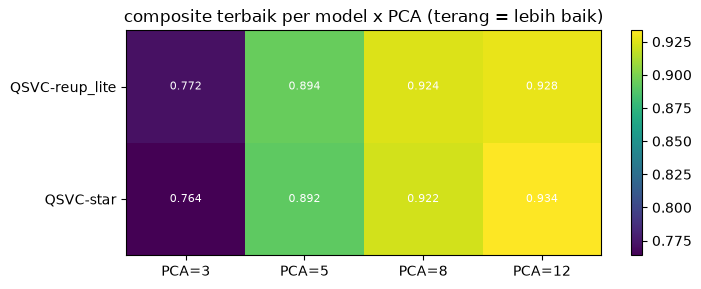

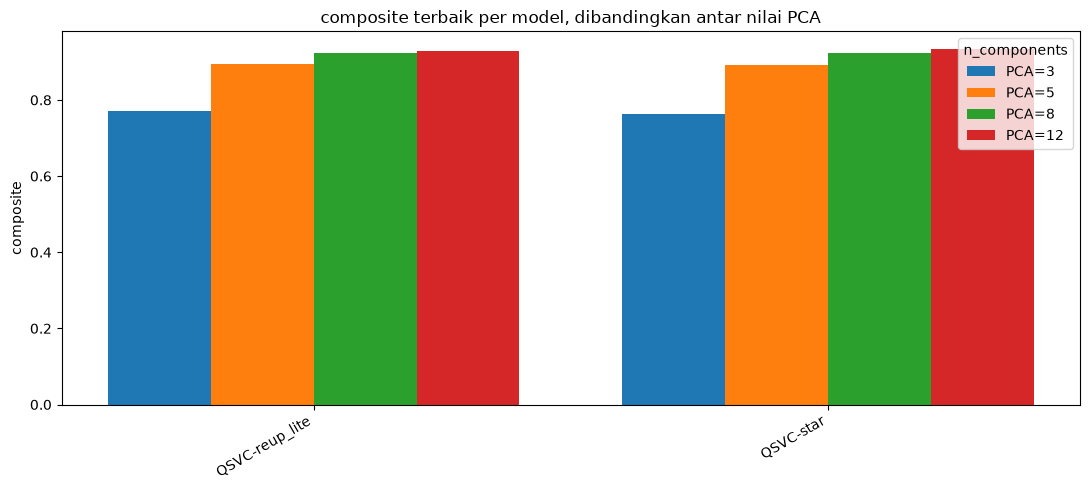

In [18]:
# === Komparasi performa per nilai PCA ===
if not USE_PCA:
    print('PCA tidak aktif (USE_PCA=False) -- tidak ada komparasi per PCA.')
else:
    res_df['pca'] = res_df['params'].apply(lambda p: p.get('pca__n_components'))
    metrics_show = ['acc', 'precision', 'recall', 'f1', 'mcc', 'auroc', 'prauc', 'composite']

    # 1) Config TERBAIK pada tiap nilai PCA (lintas semua model)
    best_per_pca = res_df.loc[res_df.groupby('pca')[select_by].idxmax()].sort_values('pca')
    print('Config terbaik pada tiap nilai PCA (lintas semua model):')
    print(best_per_pca[['pca', 'model', 'config'] + metrics_show].round(4).to_string(index=False))

    if _session['logged']:   # tulis ke log hanya jika ada kerja baru sesi ini
        log(''); log('======== KOMPARASI BEST CONFIG PER NILAI PCA (by %s) ========' % select_by)
        for _, r in best_per_pca.iterrows():
            log('PCA=%-3s | %-12s | %-32s | Acc:%.4f | F1:%.4f | MCC:%.4f | PRAUC:%.4f | Composite:%.4f' % (
                str(r['pca']), r['model'], r['config'], r['acc'], r['f1'], r['mcc'], r['prauc'], r['composite']))

    # 2) Matriks composite TERBAIK per (model x PCA)
    mat = res_df.groupby(['model', 'pca'])[select_by].max().unstack('pca')
    print('\n%s terbaik per model x PCA:' % select_by)
    print(mat.round(4).to_string())

    # 3) Heatmap matriks
    fig, ax = plt.subplots(figsize=(1.1 * len(mat.columns) + 3, 0.5 * len(mat) + 2))
    im = ax.imshow(mat.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(['PCA=%s' % c for c in mat.columns])
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            val = mat.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, '%.3f' % val, ha='center', va='center', color='w', fontsize=8)
    ax.set_title('%s terbaik per model x PCA (terang = lebih baik)' % select_by)
    plt.colorbar(im); plt.tight_layout(); savefig('05_heatmap_model_x_pca'); plt.show()

    # 4) Bar chart: composite terbaik tiap model, dibandingkan antar nilai PCA
    pcas = list(mat.columns); mdls = list(mat.index)
    x = np.arange(len(mdls)); bw = 0.8 / len(pcas)
    fig, ax = plt.subplots(figsize=(11, 5))
    for j, p in enumerate(pcas):
        ax.bar(x + (j - (len(pcas) - 1) / 2) * bw, mat[p].values, bw, label='PCA=%s' % p)
    ax.set_xticks(x); ax.set_xticklabels(mdls, rotation=30, ha='right')
    ax.set_ylabel(select_by); ax.set_title('%s terbaik per model, dibandingkan antar nilai PCA' % select_by)
    ax.legend(title='n_components'); plt.tight_layout(); savefig('06_bar_composite_per_pca_per_model'); plt.show()

## Diagnosa underfitting / overfitting

Bandingkan train vs test (CV): gap besar = overfit; dua-duanya rendah = underfit.

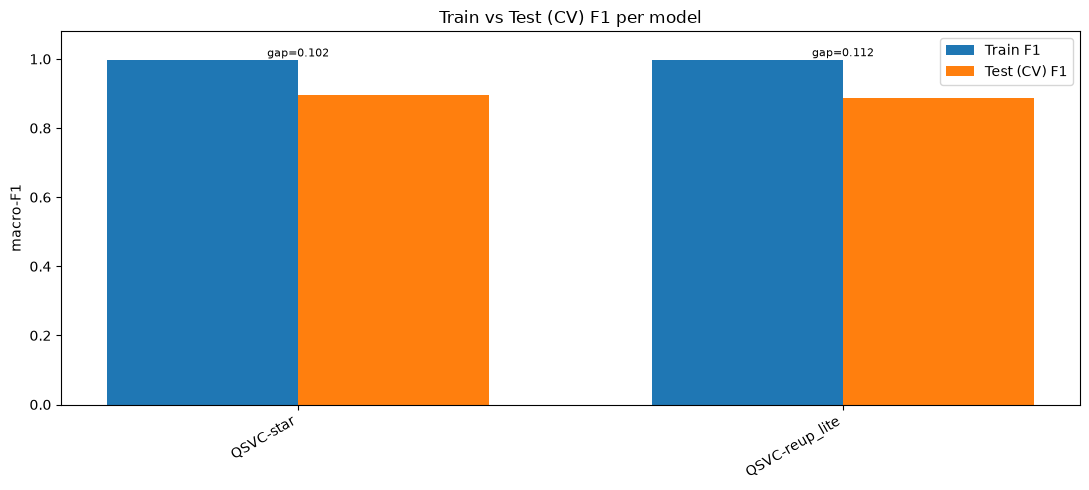

Diagnosa (gap>0.10 & train>0.85 = overfit; test<0.70 & train<0.75 = underfit):
  QSVC-star    train_f1=0.997 | test_f1=0.895 | gap=0.102 -> OVERFIT
  QSVC-reup_lite train_f1=0.998 | test_f1=0.886 | gap=0.112 -> OVERFIT


In [19]:
b = best.reset_index(drop=True)
x = np.arange(len(b)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, b['train_f1'], w, label='Train F1')
ax.bar(x + w/2, b['f1'], w, label='Test (CV) F1')
for i in range(len(b)):
    ax.text(i, max(b['train_f1'][i], b['f1'][i]) + 0.01, 'gap=%.3f' % b['gap_f1'][i], ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(b['model'], rotation=30, ha='right')
ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1.08); ax.legend()
ax.set_title('Train vs Test (CV) F1 per model'); plt.tight_layout(); savefig('07_gap_train_vs_test_f1'); plt.show()

print('Diagnosa (gap>0.10 & train>0.85 = overfit; test<0.70 & train<0.75 = underfit):')
for _, r in b.iterrows():
    if r['gap_f1'] > 0.10 and r['train_f1'] > 0.85:
        v = 'OVERFIT'
    elif r['f1'] < 0.70 and r['train_f1'] < 0.75:
        v = 'UNDERFIT'
    else:
        v = 'good fit'
    print('  %-12s train_f1=%.3f | test_f1=%.3f | gap=%.3f -> %s' % (r['model'], r['train_f1'], r['f1'], r['gap_f1'], v))

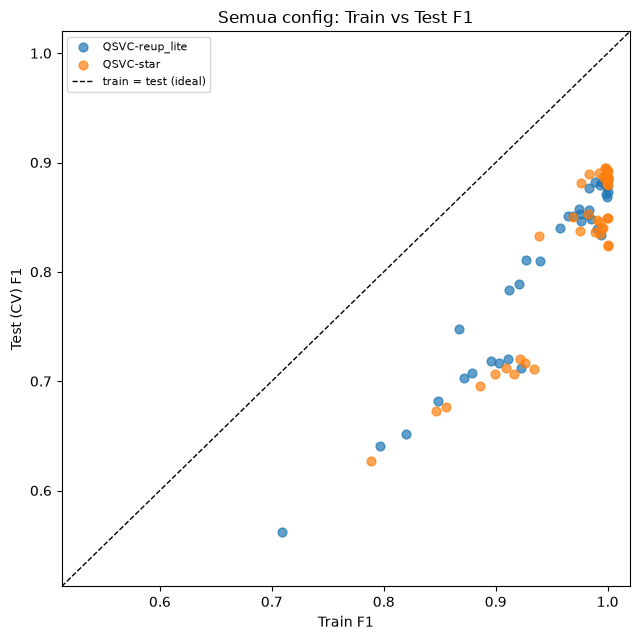

In [20]:
# Sebaran semua config: makin jauh di bawah garis diagonal = makin overfit
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for mdl, g in res_df.groupby('model'):
    ax.scatter(g['train_f1'], g['f1'], s=40, alpha=0.7, label=mdl)
lims = [min(res_df['f1'].min(), res_df['train_f1'].min()) - 0.05, 1.02]
ax.plot(lims, lims, 'k--', lw=1, label='train = test (ideal)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Train F1'); ax.set_ylabel('Test (CV) F1')
ax.set_title('Semua config: Train vs Test F1'); ax.legend(fontsize=8)
plt.tight_layout(); savefig('08_scatter_train_vs_test_f1'); plt.show()

In [21]:
# Learning curve best config TIAP model: baris atas = macro-F1, baris bawah = log-loss (DENGAN CACHE).
# F1: tinggi=baik (plafon 1.0). log-loss: RENDAH=baik -> ungkap overfit yg disembunyikan F1=1.0.
DRAW_LEARNING_CURVES = False   # set False utk lewati total

if DRAW_LEARNING_CURVES:
    import pickle
    from sklearn.model_selection import learning_curve
    from sklearn.metrics import log_loss

    def neg_log_loss_full(estimator, Xte, yte):   # scorer aman: padatkan proba ke semua kelas
        proba = estimator.predict_proba(Xte)
        full = np.zeros((proba.shape[0], len(classes)))
        for j, c in enumerate(estimator.classes_):
            full[:, int(c)] = proba[:, j]
        return -log_loss(yte, full, labels=classes)

    base_by_name = {n: bm for n, bm, _ in specs}
    bb = best.reset_index(drop=True)
    SCORINGS = [('macro-F1', 'f1_macro', False, True), ('log-loss', neg_log_loss_full, True, False)]
    sizes_frac = np.linspace(0.4, 1.0, 5)

    # ---- CACHE: hitung sekali, muat ulang kalau best-config & setup sama ----
    LC_CACHE = '../output_qml/REUP-HE_v3/lc_cache.pkl'
    lc_key = json.dumps({'configs': {r['model']: r['config'] for _, r in bb.iterrows()},
                         'cv': CV_MODE, 'n_splits': n_splits, 'rs': random_states[0],
                         'pca': USE_PCA, 'sizes': [round(float(s), 3) for s in sizes_frac]}, sort_keys=True)
    lc = None
    if os.path.exists(LC_CACHE):
        try:
            with open(LC_CACHE, 'rb') as f:
                obj = pickle.load(f)
            if obj.get('key') == lc_key:
                lc = obj['lc']
        except Exception:
            lc = None
    if lc is None:
        lc = {}
        for label, scoring, needs_proba, higher in SCORINGS:
            for _, r in bb.iterrows():
                est = make_pipe(clone(base_by_name[r['model']])); est.set_params(**r['params'])
                if r['model'].startswith('SVC'):
                    est.set_params(model__probability=needs_proba)
                sizes, tr, va = learning_curve(
                    est, X_all, y_all, groups=groups_all, cv=make_cv(random_states[0]),
                    scoring=scoring, train_sizes=sizes_frac, n_jobs=1, error_score=np.nan)
                lc[(label, r['model'])] = (sizes, tr, va)
        with open(LC_CACHE, 'wb') as f:
            pickle.dump({'key': lc_key, 'lc': lc}, f)
        print('Learning curve dihitung & disimpan ke cache:', os.path.abspath(LC_CACHE))
    else:
        print('Learning curve dimuat dari cache -- tidak fit ulang.')

    # ---- plot dari lc ----
    fig, axes = plt.subplots(len(SCORINGS), len(bb), figsize=(3.2 * len(bb), 3.4 * len(SCORINGS)), squeeze=False)
    for row, (label, scoring, needs_proba, higher) in enumerate(SCORINGS):
        for col, (_, r) in enumerate(bb.iterrows()):
            ax = axes[row][col]
            sizes, tr, va = lc[(label, r['model'])]
            tr_m, tr_s = np.nanmean(tr, 1), np.nanstd(tr, 1)
            va_m, va_s = np.nanmean(va, 1), np.nanstd(va, 1)
            if not higher:
                tr_m, va_m = -tr_m, -va_m
            ax.plot(sizes, tr_m, 'o-', color='tab:blue', label='train')
            ax.plot(sizes, va_m, 's-', color='tab:orange', label='val (CV)')
            ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, color='tab:blue', alpha=0.12)
            ax.fill_between(sizes, va_m - va_s, va_m + va_s, color='tab:orange', alpha=0.12)
            ax.grid(alpha=0.3)
            if row == 0:
                ax.set_title(r['model'], fontsize=9)
            if col == 0:
                ax.set_ylabel('%s\n(%s)' % (label, 'tinggi=baik' if higher else 'rendah=baik'), fontsize=8)
            ax.set_xlabel('jumlah sampel train', fontsize=7)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle('Learning curves per model -- macro-F1 (atas) & log-loss (bawah)')
    plt.tight_layout(); savefig('09_learning_curve_f1_logloss'); plt.show()
    print('Baca: F1 -> train & val konvergen tinggi = good fit; gap melebar = overfit; dua-duanya rendah = underfit.')
    print('      log-loss -> train ~0 sementara val tinggi = overfit (tampak walau F1 train = 1.0).')
else:
    print('Learning curves dilewati. Set DRAW_LEARNING_CURVES = False untuk menggambar.')

Learning curves dilewati. Set DRAW_LEARNING_CURVES = False untuk menggambar.


## Evaluasi per-kelas, kurva ROC/PR, kalibrasi & komparasi (OOF best config)

Memakai prediksi **out-of-fold (OOF)** dari best config tiap model (refit 7 model × 5 fold, group-aware).
Tujuan: confusion matrix per-kelas, kurva ROC/PR, kalibrasi probabilitas, dan komparasi multi-metrik antar-model
agar kesimpulan analisis bisa ditarik menyeluruh.

In [22]:
# Kumpulkan prediksi out-of-fold (OOF) utk best config tiap model (DENGAN CACHE)
import pickle
from sklearn.metrics import f1_score as _f1

base_by_name = {n: bm for n, bm, _ in specs}
best_sorted = best.sort_values('composite', ascending=False)

# kunci cache = best-config tiap model + setup CV
OOF_CACHE = '../output_qml/REUP-HE_v3/oof_cache.pkl'
oof_key = json.dumps({'configs': {r['model']: r['config'] for _, r in best_sorted.iterrows()},
                      'cv': CV_MODE, 'n_splits': n_splits, 'rs': random_states[0], 'pca': USE_PCA},
                     sort_keys=True)

_cached = None
if os.path.exists(OOF_CACHE):
    try:
        with open(OOF_CACHE, 'rb') as f:
            obj = pickle.load(f)
        if obj.get('key') == oof_key:
            _cached = obj
    except Exception:
        _cached = None

if _cached is not None:
    oof, perfold = _cached['oof'], _cached['perfold']
    oof_models = list(oof.keys())
    print('OOF dimuat dari cache (%d model) -- tidak fit ulang.' % len(oof_models))
else:
    oof, perfold = {}, {}
    for _, r in best_sorted.iterrows():
        m = r['model']; eb = base_by_name[m]
        Y, P, PR = [], [], []
        pf = {'acc': [], 'f1': [], 'mcc': [], 'auroc': [], 'prauc': []}
        for tr, te in make_cv(random_states[0]).split(X_all, y_all, groups_all):
            pipe = make_pipe(clone(eb)); pipe.set_params(**r['params'])
            pipe.fit(X_all[tr], y_all[tr])
            proba = pipe.predict_proba(X_all[te])
            full = np.zeros((len(te), len(classes)))                 # padatkan ke semua kelas
            for j, c in enumerate(pipe.classes_):
                full[:, int(c)] = proba[:, j]
            pred = np.asarray(pipe.predict(X_all[te])).ravel().astype(int)
            acc, prec, rec, f1, mcc, au, prc = fold_metrics(y_all[te], pred, full)
            pf['acc'].append(acc); pf['f1'].append(f1); pf['mcc'].append(mcc); pf['auroc'].append(au); pf['prauc'].append(prc)
            Y.append(y_all[te]); P.append(pred); PR.append(full)
        oof[m] = {'y': np.concatenate(Y), 'pred': np.concatenate(P), 'proba': np.vstack(PR)}
        perfold[m] = pf
        print('OOF %-12s dihitung (%d sampel, F1=%.3f)' % (m, len(oof[m]['y']), _f1(oof[m]['y'], oof[m]['pred'], average='macro')))
    oof_models = list(oof.keys())
    with open(OOF_CACHE, 'wb') as f:
        pickle.dump({'key': oof_key, 'oof': oof, 'perfold': perfold}, f)
    print('OOF disimpan ke cache:', os.path.abspath(OOF_CACHE))

OOF QSVC-star    dihitung (10409 sampel, F1=0.897)
OOF QSVC-reup_lite dihitung (10409 sampel, F1=0.888)
OOF disimpan ke cache: e:\Quantum Computing\Github\quantum-multiclass-classification\output_qml\REUP-HE_v3\oof_cache.pkl


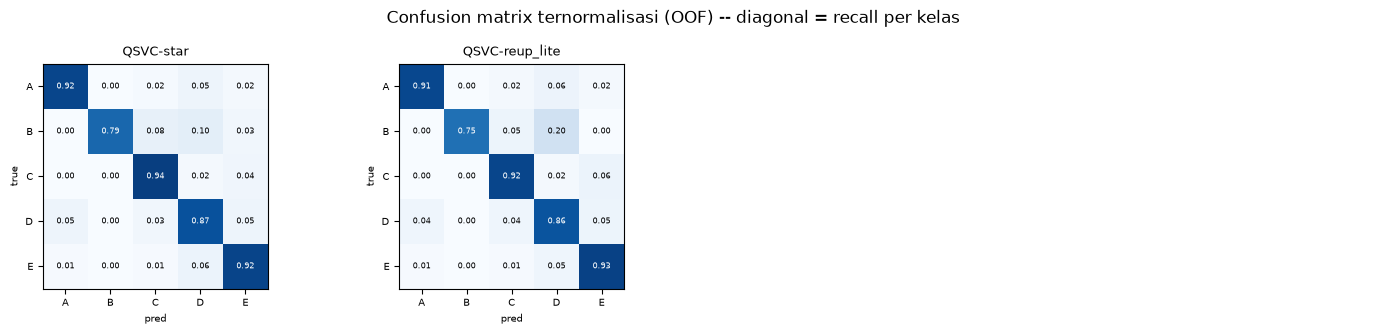

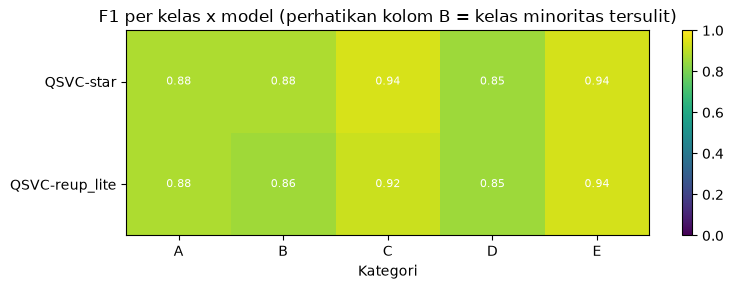

In [23]:
# PRIORITAS 1 -- Confusion matrix (ternormalisasi) + F1 per kelas
from sklearn.metrics import confusion_matrix, f1_score

ncol = 4; nrow = int(np.ceil(len(oof_models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.3 * nrow)); axes = np.array(axes).ravel()
for ax, m in zip(axes, oof_models):
    cm = confusion_matrix(oof[m]['y'], oof[m]['pred'], labels=classes).astype(float)
    denom = cm.sum(1, keepdims=True)
    cmn = np.divide(cm, denom, out=np.zeros_like(cm), where=denom > 0)   # normalisasi per kelas asli (diagonal = recall)
    ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=7)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, '%.2f' % cmn[i, j], ha='center', va='center', fontsize=6,
                    color='white' if cmn[i, j] > 0.5 else 'black')
    ax.set_title(m, fontsize=9); ax.set_xlabel('pred', fontsize=7); ax.set_ylabel('true', fontsize=7)
for ax in axes[len(oof_models):]:
    ax.axis('off')
plt.suptitle('Confusion matrix ternormalisasi (OOF) -- diagonal = recall per kelas')
plt.tight_layout(); savefig('10_confusion_matrix'); plt.show()

# Heatmap F1 per kelas x model (kolom B = kelas tersulit)
f1mat = np.array([f1_score(oof[m]['y'], oof[m]['pred'], labels=classes, average=None, zero_division=0) for m in oof_models])
fig, ax = plt.subplots(figsize=(1.0 * len(names) + 3, 0.5 * len(oof_models) + 2))
im = ax.imshow(f1mat, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
ax.set_yticks(range(len(oof_models))); ax.set_yticklabels(oof_models)
for i in range(len(oof_models)):
    for j in range(len(names)):
        ax.text(j, i, '%.2f' % f1mat[i, j], ha='center', va='center', color='w', fontsize=8)
ax.set_title('F1 per kelas x model (perhatikan kolom B = kelas minoritas tersulit)')
ax.set_xlabel('Kategori'); plt.colorbar(im); plt.tight_layout(); savefig('11_f1_per_kelas_heatmap'); plt.show()

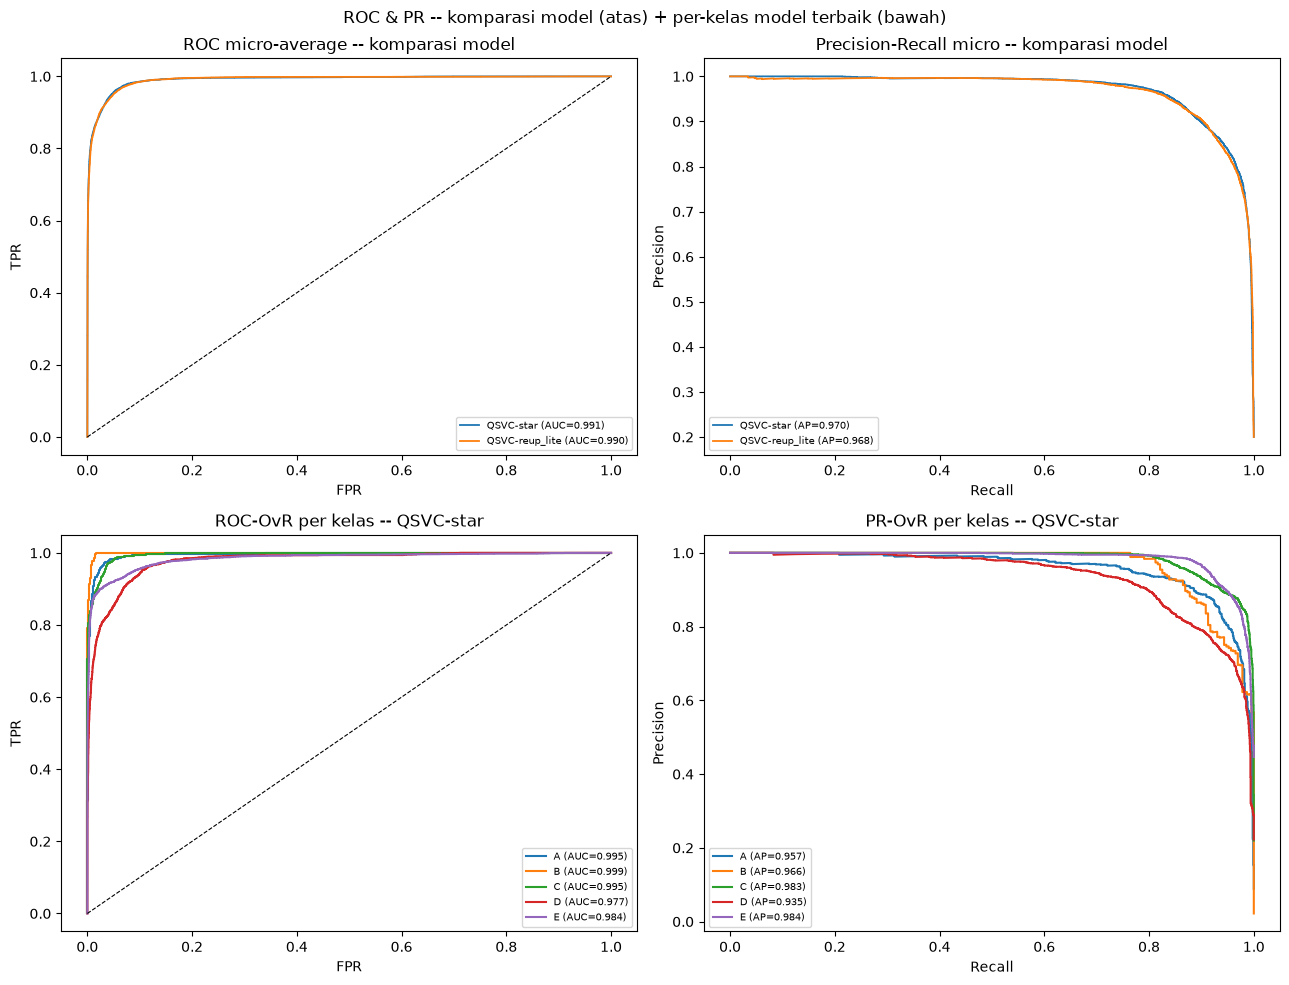

In [24]:
# PRIORITAS 2 -- Kurva ROC & Precision-Recall (One-vs-Rest)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
# Atas: komparasi antar-model (micro-average)
ax = axes[0, 0]
for m in oof_models:
    Yb = label_binarize(oof[m]['y'], classes=classes)
    fpr, tpr, _ = roc_curve(Yb.ravel(), oof[m]['proba'].ravel())
    ax.plot(fpr, tpr, lw=1.3, label='%s (AUC=%.3f)' % (m, auc(fpr, tpr)))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC micro-average -- komparasi model'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=7)

ax = axes[0, 1]
for m in oof_models:
    Yb = label_binarize(oof[m]['y'], classes=classes)
    pr, rc, _ = precision_recall_curve(Yb.ravel(), oof[m]['proba'].ravel())
    ax.plot(rc, pr, lw=1.3, label='%s (AP=%.3f)' % (m, average_precision_score(Yb, oof[m]['proba'], average='micro')))
ax.set_title('Precision-Recall micro -- komparasi model'); ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=7)

# Bawah: per-kelas utk model terbaik (oof_models[0])
bm = oof_models[0]; Yb = label_binarize(oof[bm]['y'], classes=classes)
ax = axes[1, 0]
for i, c in enumerate(names):
    fpr, tpr, _ = roc_curve(Yb[:, i], oof[bm]['proba'][:, i])
    ax.plot(fpr, tpr, label='%s (AUC=%.3f)' % (c, auc(fpr, tpr)))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC-OvR per kelas -- %s' % bm); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=7)

ax = axes[1, 1]
for i, c in enumerate(names):
    pr, rc, _ = precision_recall_curve(Yb[:, i], oof[bm]['proba'][:, i])
    ax.plot(rc, pr, label='%s (AP=%.3f)' % (c, average_precision_score(Yb[:, i], oof[bm]['proba'][:, i])))
ax.set_title('PR-OvR per kelas -- %s' % bm); ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=7)

plt.suptitle('ROC & PR -- komparasi model (atas) + per-kelas model terbaik (bawah)')
plt.tight_layout(); savefig('12_roc_pr_ovr'); plt.show()

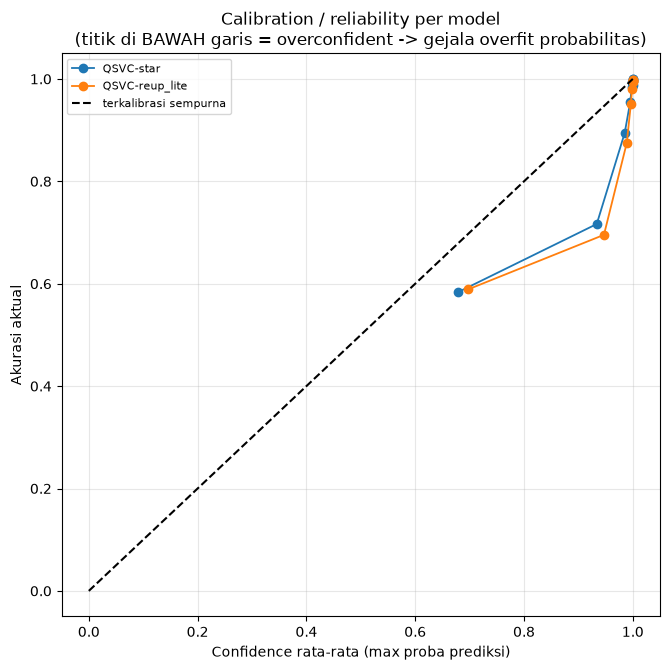

In [25]:
# PRIORITAS 3 -- Calibration / reliability (membuktikan overfit probabilitas dari log-loss)
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6.8, 6.8))
for m in oof_models:
    conf = oof[m]['proba'].max(1)                          # confidence kelas yang diprediksi
    correct = (oof[m]['pred'] == oof[m]['y']).astype(int)  # benar/tidak
    fp, mp = calibration_curve(correct, conf, n_bins=10, strategy='quantile')
    ax.plot(mp, fp, 'o-', lw=1.3, label=m)
ax.plot([0, 1], [0, 1], 'k--', label='terkalibrasi sempurna')
ax.set_xlabel('Confidence rata-rata (max proba prediksi)')
ax.set_ylabel('Akurasi aktual')
ax.set_title('Calibration / reliability per model\n(titik di BAWAH garis = overconfident -> gejala overfit probabilitas)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); savefig('13_calibration'); plt.show()

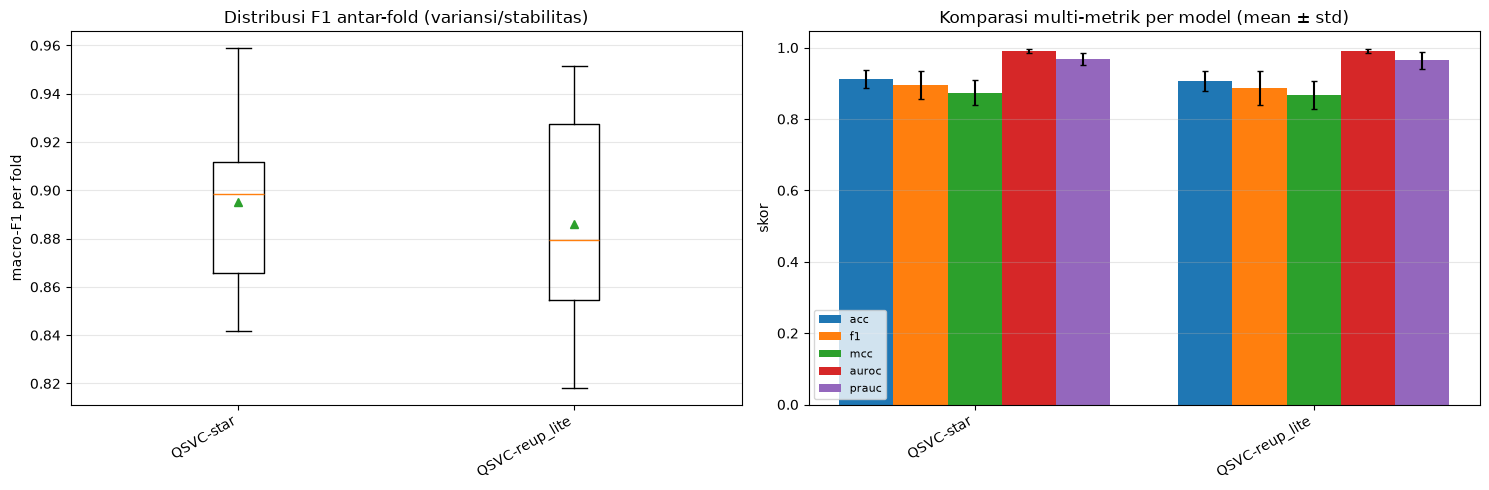

Kesimpulan bisa ditarik dari: (1) confusion matrix + F1/kelas -> kelas mana lemah (B),
(2) ROC/PR -> kualitas ranking & komparasi model, (3) calibration -> keandalan probabilitas,
(4) box per-fold + bar multi-metrik -> model mana terbaik & paling stabil.


In [26]:
# PRIORITAS 4 -- Box per-fold (variansi) + komparasi multi-metrik (mean ± std)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box F1 antar-fold per model -> lihat stabilitas/variansi
ax = axes[0]
ax.boxplot([perfold[m]['f1'] for m in oof_models], showmeans=True)
ax.set_xticks(range(1, len(oof_models) + 1)); ax.set_xticklabels(oof_models, rotation=30, ha='right')
ax.set_ylabel('macro-F1 per fold'); ax.set_title('Distribusi F1 antar-fold (variansi/stabilitas)')
ax.grid(alpha=0.3, axis='y')

# Grouped bar multi-metrik (mean ± std) dari hasil HPO
ax = axes[1]
bb = best.set_index('model').loc[oof_models]
mets = ['acc', 'f1', 'mcc', 'auroc', 'prauc']
xx = np.arange(len(oof_models)); w = 0.16
for k, met in enumerate(mets):
    err = bb[met + '_std'].values if (met + '_std') in bb.columns else None
    ax.bar(xx + (k - 2) * w, bb[met].values, w, yerr=err, capsize=2, label=met)
ax.set_xticks(xx); ax.set_xticklabels(oof_models, rotation=30, ha='right')
ax.set_ylabel('skor'); ax.set_title('Komparasi multi-metrik per model (mean ± std)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); savefig('14_box_perfold_multimetrik'); plt.show()

print('Kesimpulan bisa ditarik dari: (1) confusion matrix + F1/kelas -> kelas mana lemah (B),')
print('(2) ROC/PR -> kualitas ranking & komparasi model, (3) calibration -> keandalan probabilitas,')
print('(4) box per-fold + bar multi-metrik -> model mana terbaik & paling stabil.')

## Composite score & efisiensi pencarian (model tercepat capai best)

Pakai seluruh hasil HPO (semua config) untuk melihat sebaran Composite tiap model dan
**model mana paling cepat/robust mencapai best composite-nya** (sedikit config sudah near-best).
Catatan: "cepat" di sini = efisiensi pencarian (jumlah config), bukan waktu training (tidak dicatat di log).

Efisiensi pencarian (exp_trials_near_best rendah = cepat menemukan best):
         model  n_config  best  mean   std  pct_near_best  exp_trials_near_best
     QSVC-star        40 0.934 0.868 0.070           17.5                 5.714
QSVC-reup_lite        40 0.928 0.860 0.072           27.5                 3.636


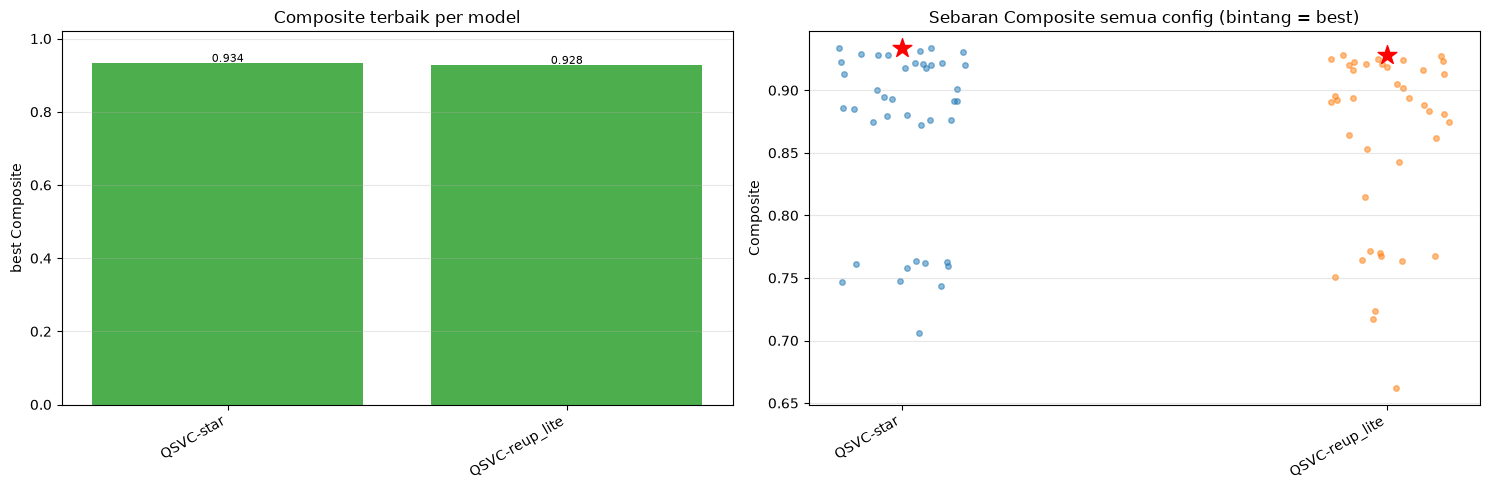

In [27]:
# Composite score per model + sebaran semua config + tabel efisiensi pencarian
rng = np.random.default_rng(0)
TOL = 0.01  # toleransi "near-best"
models_order = best.sort_values('composite', ascending=False)['model'].tolist()

rows = []
for m in models_order:
    s = res_df[res_df['model'] == m]['composite'].values
    bc = s.max()
    near = float((s >= bc - TOL).mean())                     # fraksi config near-best
    rows.append({'model': m, 'n_config': len(s), 'best': bc, 'mean': s.mean(), 'std': s.std(),
                 'pct_near_best': 100 * near,
                 'exp_trials_near_best': (1.0 / near) if near > 0 else np.nan})
eff = pd.DataFrame(rows)
print('Efisiensi pencarian (exp_trials_near_best rendah = cepat menemukan best):')
print(eff.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Kiri: best Composite per model (bar)
ax = axes[0]
ax.bar(range(len(models_order)), eff['best'], color='tab:green', alpha=0.85)
for i, v in enumerate(eff['best']):
    ax.text(i, v + 0.003, '%.3f' % v, ha='center', fontsize=8)
ax.set_xticks(range(len(models_order))); ax.set_xticklabels(models_order, rotation=30, ha='right')
ax.set_ylabel('best Composite'); ax.set_ylim(0, 1.02); ax.set_title('Composite terbaik per model')
ax.grid(alpha=0.3, axis='y')
# Kanan: sebaran semua config (strip) + best (bintang)
ax = axes[1]
for i, m in enumerate(models_order):
    s = res_df[res_df['model'] == m]['composite'].values
    ax.scatter(i + rng.uniform(-0.13, 0.13, len(s)), s, alpha=0.5, s=16)
    ax.scatter([i], [s.max()], marker='*', s=200, color='red', zorder=5)
ax.set_xticks(range(len(models_order))); ax.set_xticklabels(models_order, rotation=30, ha='right')
ax.set_ylabel('Composite'); ax.set_title('Sebaran Composite semua config (bintang = best)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); savefig('15_composite_score_sebaran'); plt.show()

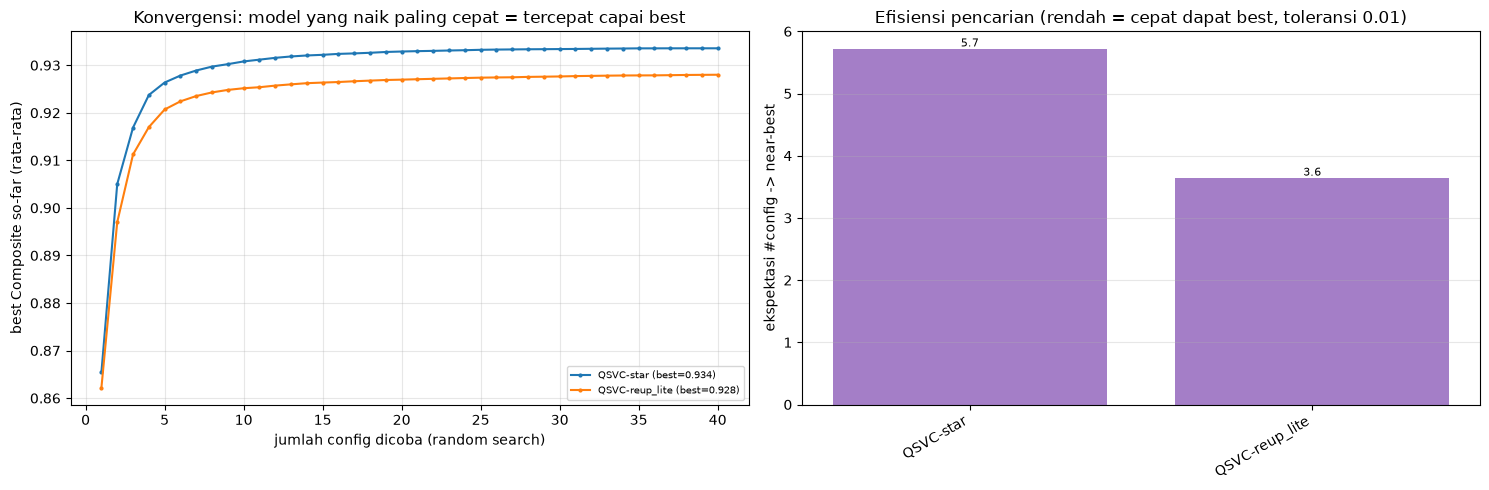

Paling cepat/robust capai best: QSVC-reup_lite (28% config near-best, ~3.6 config rata-rata)


In [28]:
# Kurva konvergensi random-search: best Composite "so-far" vs jumlah config dicoba
# (rata-rata atas banyak urutan acak) -> naik paling cepat = paling cepat menemukan best.
n_perm = 300
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for m in models_order:
    s = res_df[res_df['model'] == m]['composite'].values
    n = len(s)
    curve = np.zeros(n)
    for _ in range(n_perm):
        curve += np.maximum.accumulate(rng.permutation(s))
    curve /= n_perm
    ax.plot(range(1, n + 1), curve, marker='.', ms=4, label='%s (best=%.3f)' % (m, s.max()))
ax.set_xlabel('jumlah config dicoba (random search)')
ax.set_ylabel('best Composite so-far (rata-rata)')
ax.set_title('Konvergensi: model yang naik paling cepat = tercepat capai best')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Bar: ekspektasi #config utk near-best (rendah = cepat)
ax = axes[1]
ax.bar(range(len(eff)), eff['exp_trials_near_best'], color='tab:purple', alpha=0.85)
for i, v in enumerate(eff['exp_trials_near_best']):
    ax.text(i, v, '%.1f' % v, ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(eff))); ax.set_xticklabels(eff['model'], rotation=30, ha='right')
ax.set_ylabel('ekspektasi #config -> near-best')
ax.set_title('Efisiensi pencarian (rendah = cepat dapat best, toleransi %.2f)' % TOL)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); savefig('16_konvergensi_efisiensi'); plt.show()

fastest = eff.loc[eff['exp_trials_near_best'].idxmin()]
print('Paling cepat/robust capai best: %s (%.0f%% config near-best, ~%.1f config rata-rata)' % (
    fastest['model'], fastest['pct_near_best'], fastest['exp_trials_near_best']))